In [1]:
#!pip install ema_workbench

In [2]:
#!pip install ipython-autotime
%load_ext autotime

time: 542 µs (started: 2024-01-14 20:02:34 -03:00)


In [3]:
#import warnings
#warnings.simplefilter('module')

time: 294 µs (started: 2024-01-14 20:02:34 -03:00)


In [4]:
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

time: 31.7 s (started: 2024-01-14 20:02:34 -03:00)


## **Performance/Reliability/Cost Analysis Model**

In [44]:
from ema_workbench import (RealParameter, IntegerParameter, ScalarOutcome, Constant, Model)
from ema_workbench import (MultiprocessingEvaluator, ema_logging, perform_experiments)
from ema_workbench.analysis import pairs_plotting
from ema_workbench.analysis import prim
from ema_workbench.analysis import feature_scoring
from ema_workbench.em_framework.evaluators import Samplers
from ema_workbench.em_framework.salib_samplers import get_SALib_problem
from ema_workbench import Policy

from SALib.analyze import sobol

ema_logging.log_to_stderr(ema_logging.INFO)

<Logger EMA (DEBUG)>

time: 86.8 ms (started: 2024-01-16 01:01:58 -03:00)


In [6]:
def countActiveDevices(d1Services, d2Services, d3Services):
    count_activeDevices = 0
    if d1Services > 0:
        count_activeDevices = count_activeDevices + 1
    if d2Services > 0:
        count_activeDevices = count_activeDevices + 1
    if d3Services > 0:
        count_activeDevices = count_activeDevices + 1

    return count_activeDevices

def getTotalCost(d1Services, d2Services, d3Services, deviceCost, serviceCost):
    count_activeServices = d1Services + d2Services + d3Services
    count_activeDevices = countActiveDevices(d1Services, d2Services, d3Services)

    result = count_activeDevices*deviceCost + count_activeServices*serviceCost
    return result

# Test
getTotalCost(3,0,1,20,2)

48

time: 16.3 ms (started: 2024-01-14 20:03:19 -03:00)


In [7]:
def getExecutionTime(d1Services, d2Services, d3Services, lbExecTime, deviceCPUCyles, serviceFailureProb):
    count_activeDevices = countActiveDevices(d1Services, d2Services, d3Services)
    if count_activeDevices == 0:
        count_activeDevices = 1

    result = lbExecTime + (1 - serviceFailureProb/100) * 0.5 * deviceCPUCyles / count_activeDevices
    return math.ceil(result)

# Test
getExecutionTime(3,0,1,10,120,30)

31

time: 11 ms (started: 2024-01-14 20:03:19 -03:00)


In [8]:
def getProbabilitySuccessfulExecution(d1Services, d2Services, d3Services, lbFailureProb, serviceFailureProb):
    count_activeDevices = countActiveDevices(d1Services, d2Services, d3Services)

    result = 100 * (1 - lbFailureProb/100) * (1 - math.pow(serviceFailureProb/100, count_activeDevices))
    return math.ceil(result)

# Test
getProbabilitySuccessfulExecution(3,0,1,20,30)

73

time: 9.15 ms (started: 2024-01-14 20:03:19 -03:00)


In [9]:
# Constants (default values)
Default_deviceCost = 20
Default_serviceCost = 2
Default_lbExectTime = 30
Default_deviceCPUCyles = 120
Default_lbFailureProb = 20
Default_serviceFailureProb = 30
Default_dServices = 1

def modelFunction(d1Services= Default_dServices,
                  d2Services= Default_dServices,
                  d3Services= Default_dServices,
                  deviceCost = Default_deviceCost,
                  serviceCost = Default_serviceCost,
                  lbExecTime = Default_lbExectTime,
                  deviceCPUCyles = Default_deviceCPUCyles,
                  serviceFailureProb = Default_serviceFailureProb,
                  lbFailureProb = Default_lbFailureProb):

    cost = getTotalCost(d1Services, d2Services, d3Services, deviceCost, serviceCost)
    executionTime = getExecutionTime(d1Services, d2Services, d3Services, lbExecTime, deviceCPUCyles, serviceFailureProb)
    probSuccessfulExecution = getProbabilitySuccessfulExecution(d1Services, d2Services, d3Services, lbFailureProb, serviceFailureProb)

    # Outcomes
    return cost, executionTime, probSuccessfulExecution

# Test
#modelFunction(2,1,0,20,2,10,120,30, 20)
modelFunction(2,1,0)

(46, 51, 73)

time: 12.1 ms (started: 2024-01-14 20:03:19 -03:00)


In [46]:
model = Model('archexploration', function=modelFunction)

#specify uncertainties
model.uncertainties = [IntegerParameter('deviceCost', 0, 40),
                       IntegerParameter('serviceCost', 1, 5),
                       IntegerParameter('lbExecTime', 10, 50),
                       IntegerParameter('deviceCPUCyles', 100, 150),
                       IntegerParameter('serviceFailureProb', 10, 50),
                       IntegerParameter('lbFailureProb', 10, 50)]

# set levers
model.levers = [IntegerParameter("d1Services", 0, 6), # This is selecting only 1 alternative!
                IntegerParameter("d2Services", 0, 6),
                IntegerParameter("d3Services", 0, 6)]

#specify outcomes
model.outcomes = [ScalarOutcome('cost'),
                  ScalarOutcome('executionTime'),
                  ScalarOutcome('probSuccessfulExecution')]

time: 35.9 ms (started: 2024-01-16 01:02:29 -03:00)


### **Generation of scenarios (dataset)**

In [47]:
from ema_workbench import MultiprocessingEvaluator

#with MultiprocessingEvaluator(model) as evaluator:
#    results = evaluator.perform_experiments(scenarios=100, policies=10)
results = perform_experiments(models=model, scenarios=500, policies=400, lever_sampling=Samplers.FF) # Full factorial

[MainProcess/INFO] performing 500 scenarios * 343 policies * 1 model(s) = 171500 experiments
100%|████████████████████████████████| 171500/171500 [00:44<00:00, 3877.35it/s]
[MainProcess/INFO] experiments finished


time: 44.3 s (started: 2024-01-16 01:02:31 -03:00)


In [12]:
from ema_workbench import save_results
from ema_workbench import load_results

save_results(results, 'archexploration_500scenarios_400policies.tar.gz')
#results = load_results('archexploration_500scenarios_350policies.tar.gz')

[MainProcess/INFO] results saved successfully to /Users/adiazpace/Documents/my-research/explainability-cmu/robustness/archexploration_500scenarios_400policies.tar.gz


time: 3.52 s (started: 2024-01-14 20:04:31 -03:00)


In [13]:
# Fix configuration for parameters (no uncertainties)
model.uncertainties = [IntegerParameter('deviceCost', 0, 20), # Sobol
                       IntegerParameter('serviceCost', 1, 4), # Sobol
                       IntegerParameter('lbExecTime', 10, 37), # Sobol
                       IntegerParameter('deviceCPUCyles', 100, 150),
                       IntegerParameter('serviceFailureProb', 10, 50),
                       IntegerParameter('lbFailureProb', 10, 33)] # Sobol

# set levers
model.levers = [IntegerParameter("d1Services", 2, 2), # This is selecting only 1 alternative!
                IntegerParameter("d2Services", 5, 5),
                IntegerParameter("d3Services", 1, 1)]

results = perform_experiments(models=model, scenarios=500, policies=1)
#save_results(results, 'archexploration_500scenarios_1policies.tar.gz')
#save_results(results, 'archexploration_500scenarios_64policies.tar.gz')
save_results(results, 'archexploration_500scenarios_1policies_sobol.tar.gz')
#save_results(results, 'archexploration_1scenarios_500policies_prim.tar.gz')

[MainProcess/INFO] performing 500 scenarios * 1 policies * 1 model(s) = 500 experiments
100%|██████████████████████████████████████| 500/500 [00:00<00:00, 1897.88it/s]
[MainProcess/INFO] experiments finished
[MainProcess/INFO] results saved successfully to /Users/adiazpace/Documents/my-research/explainability-cmu/robustness/archexploration_500scenarios_1policies_sobol.tar.gz


time: 322 ms (started: 2024-01-14 20:04:35 -03:00)


In [48]:
experiments_df, outcomes = results
policies = experiments_df['policy']
print(experiments_df.shape)
print(list(outcomes.keys()))

(171500, 12)
['cost', 'executionTime', 'probSuccessfulExecution']
time: 4.95 ms (started: 2024-01-16 01:03:23 -03:00)


In [51]:
experiments_df.sample(30)

,deviceCPUCyles,deviceCost,lbExecTime,lbFailureProb,serviceCost,serviceFailureProb,d1Services,d2Services,d3Services,scenario,policy,model
155293,143,30,49,18,4,21,6,2,2,4281,3955,archexploration
45748,133,22,21,41,3,38,1,6,0,4236,3736,archexploration
133417,125,26,34,29,1,50,5,3,0,4405,3911,archexploration
123255,104,18,34,24,4,29,5,0,1,4243,3891,archexploration
142630,119,6,23,22,1,15,5,5,5,4118,3930,archexploration
73155,150,25,46,17,4,46,2,6,6,4143,3791,archexploration
17965,145,22,43,40,4,31,0,5,0,4453,3680,archexploration
100982,139,17,18,40,5,21,4,0,5,4470,3846,archexploration
3032,116,3,50,12,5,40,0,0,6,4020,3651,archexploration
87265,144,5,16,42,5,43,3,3,6,4253,3819,archexploration


time: 29.2 ms (started: 2024-01-16 01:03:59 -03:00)


In [16]:
config_0_0_0_to_remove = experiments_df[(experiments_df.d1Services==0)&(experiments_df.d2Services==0)&(experiments_df.d3Services==0)].index
experiments_df.drop(experiments_df.index[config_0_0_0_to_remove], inplace=True)
experiments_df.reset_index(drop=True, inplace=True)
experiments_df

,deviceCPUCyles,deviceCost,lbExecTime,lbFailureProb,serviceCost,serviceFailureProb,d1Services,d2Services,d3Services,scenario,policy,model
0,118,4,19,20,2,24,2,5,1,844,843,archexploration
1,132,1,23,19,4,12,2,5,1,845,843,archexploration
2,119,16,10,22,3,48,2,5,1,846,843,archexploration
3,138,17,26,10,4,20,2,5,1,847,843,archexploration
4,114,7,21,24,1,39,2,5,1,848,843,archexploration
...,...,...,...,...,...,...,...,...,...,...,...,...
495,102,18,13,10,4,47,2,5,1,1339,843,archexploration
496,138,9,17,33,3,18,2,5,1,1340,843,archexploration
497,143,13,31,23,3,33,2,5,1,1341,843,archexploration
498,111,12,36,24,1,12,2,5,1,1342,843,archexploration


time: 22.4 ms (started: 2024-01-14 20:04:35 -03:00)


In [17]:
outcomes_df = pd.DataFrame(outcomes)
outcomes_df.drop(outcomes_df.index[config_0_0_0_to_remove], inplace=True)
outcomes_df.reset_index(drop=True, inplace=True)
outcomes_df

,cost,executionTime,probSuccessfulExecution
0,28,34,79
1,35,43,81
2,72,21,70
3,83,45,90
4,29,33,72
...,...,...,...
495,86,23,81
496,51,36,67
497,63,47,75
498,44,53,76


time: 12.7 ms (started: 2024-01-14 20:04:35 -03:00)


In [18]:
outcomes_df.describe()

,cost,executionTime,probSuccessfulExecution
count,500.000000,500.000000,500.000000
mean,50.000000,38.548000,75.854000
std,20.600893,8.559335,7.217539
min,8.000000,21.000000,60.000000
25%,34.000000,32.000000,70.000000
50%,50.000000,39.000000,76.000000
75%,66.000000,45.000000,82.000000
max,92.000000,59.000000,90.000000


time: 30.7 ms (started: 2024-01-14 20:04:35 -03:00)


In [19]:
def filter_architecture(experiments, outcomes, dServices):
    d1Services = dServices[0]
    d2Services = dServices[1]
    d3Services = dServices[2]
    exp_filter = experiments[(experiments['d1Services']==d1Services)&(experiments['d2Services']==d2Services)&(experiments['d3Services']==d3Services)]
    policy = exp_filter['policy'].unique()
    #print('policies:', policy)
    if len(policy) > 0:
        exp_filter = exp_filter[exp_filter['policy'] == policy[0]]
    exp_outcomes = dict()
    for k in outcomes.keys():
        exp_outcomes[k] = outcomes[k][exp_filter.index]
    
    return exp_filter, exp_outcomes

time: 1.69 ms (started: 2024-01-14 20:04:36 -03:00)


In [21]:
import itertools
import random

#OPTIONS = [[1, 2, 3], [4, 5, 6], [0, 1, 2]]
#OPTIONS = [[0, 1, 2, 3], [3, 4, 5, 6], [0, 1, 2, 3]]
OPTIONS = [list(range(7)), list(range(7)), list(range(7))]

all_combinations = [list(x) for x in itertools.product(*OPTIONS)]
#config = random.choice(all_combinations)
#print(config, "configuation, out of", len(all_combinations), "combinations (policies)")

for c in all_combinations:
    exp_filtered, exp_outcomes = filter_architecture(experiments_df, outcomes, c)
    if exp_filtered.shape[0] == 0:
        print("Warning: configuration", c, "was not sampled!")

time: 699 ms (started: 2024-01-14 20:05:25 -03:00)


### **Visualization of policies**

In [22]:
def show_pairplot(experiments, outcomes, kind='sns', title='', group='policy'):
    if kind == 'sns':
        policies = experiments['policy']
        data = pd.DataFrame(outcomes)
        data['policy'] = policies
        g = sns.pairplot(data, hue=group, vars=list(outcomes.keys()), corner=True, plot_kws={'alpha':0.25})
        g._legend.remove()
        g.fig.suptitle(title)
        #plt.savefig('single-configurations-210.png')
        plt.show()
    if kind == 'matplotlib':
        data = experiments.copy()
        data['policy'] = experiments['policy'].astype(str)
        fig, axes = pairs_plotting.pairs_scatter(data, outcomes, group_by=group,legend=False)
        fig.set_size_inches(8,8)
        fig.suptitle(title)
        #plt.savefig('all-configurations-uncertainty.png')
        plt.show()

time: 2.65 ms (started: 2024-01-14 20:05:37 -03:00)


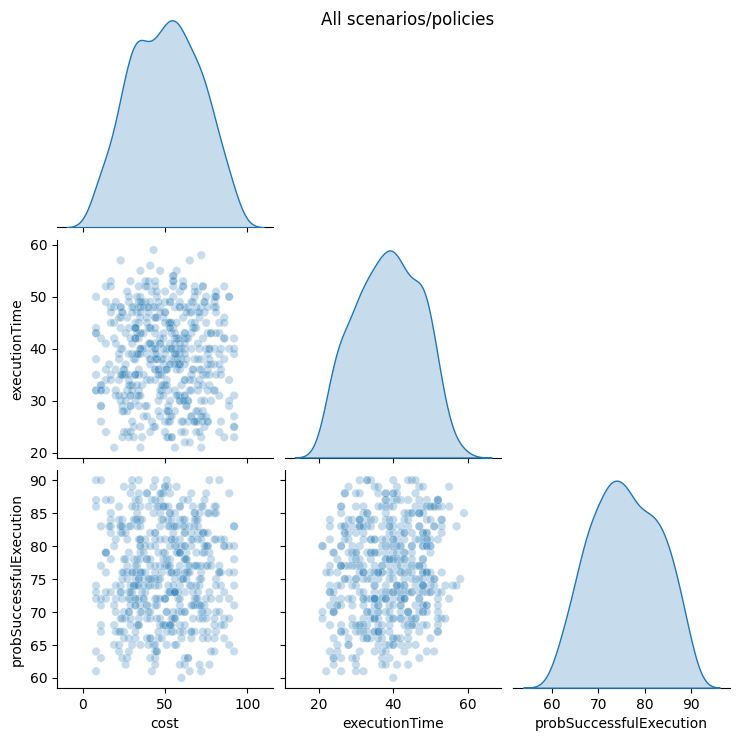

time: 3.14 s (started: 2024-01-14 20:05:46 -03:00)


In [24]:
show_pairplot(experiments_df, outcomes, title='All scenarios/policies')

[MainProcess/INFO] no time dimension found in results


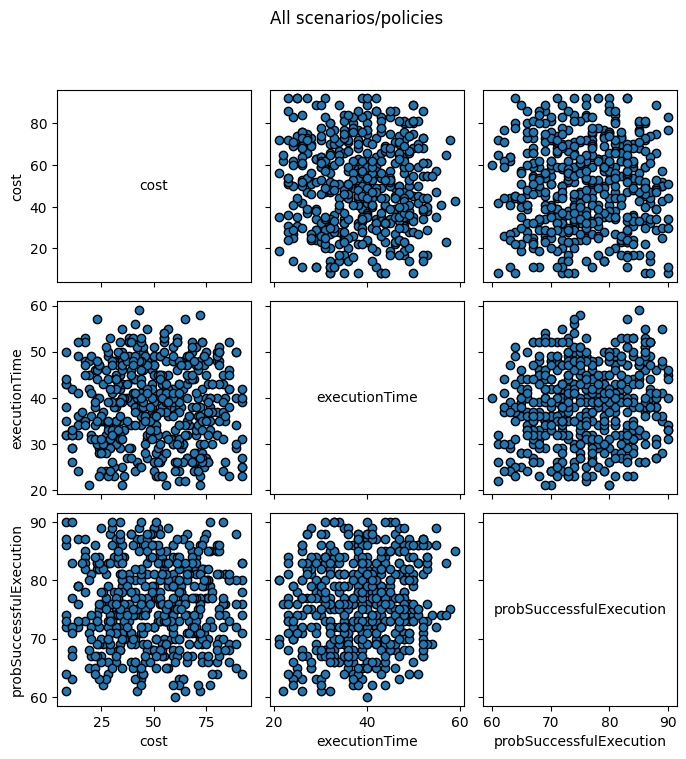

time: 1.17 s (started: 2024-01-14 20:05:53 -03:00)


In [25]:
show_pairplot(experiments_df, outcomes, kind='matplotlib', title='All scenarios/policies')

In [26]:
config = [1,5,2]
exp_filtered, exp_outcomes = filter_architecture(experiments_df, outcomes, config)
exp_filtered

,deviceCPUCyles,deviceCost,lbExecTime,lbFailureProb,serviceCost,serviceFailureProb,d1Services,d2Services,d3Services,scenario,policy,model


time: 8.71 ms (started: 2024-01-14 20:06:03 -03:00)


In [27]:
pd.DataFrame(exp_outcomes).describe()

,cost,executionTime,probSuccessfulExecution
count,0.0,0.0,0.0
mean,NaN,NaN,NaN
std,NaN,NaN,NaN
min,NaN,NaN,NaN
25%,NaN,NaN,NaN
50%,NaN,NaN,NaN
75%,NaN,NaN,NaN
max,NaN,NaN,NaN


time: 15.3 ms (started: 2024-01-14 20:06:07 -03:00)


[MainProcess/INFO] no time dimension found in results


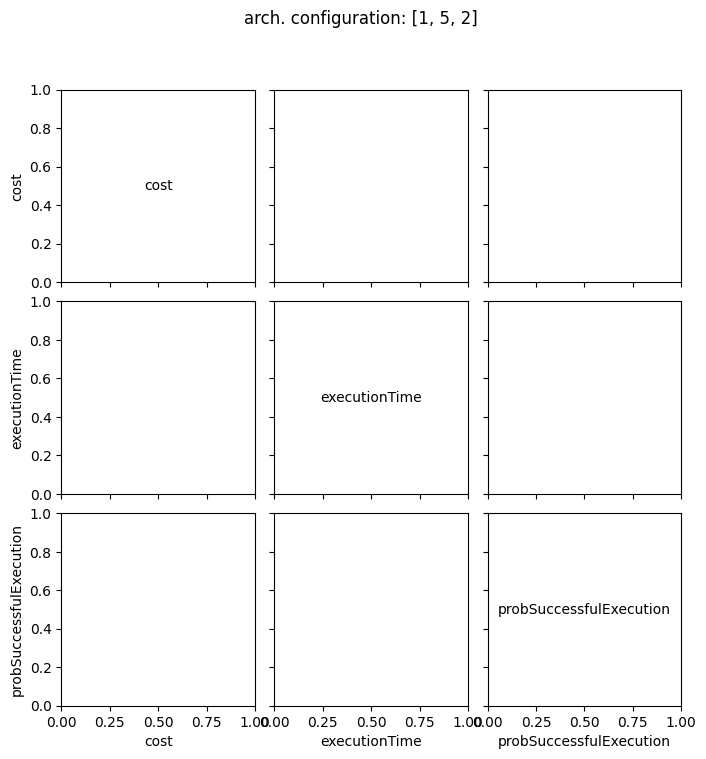

time: 963 ms (started: 2024-01-14 20:06:10 -03:00)


In [28]:
show_pairplot(exp_filtered, exp_outcomes, kind='matplotlib', title='arch. configuration: '+str(config))

### **Feature scoring (w.r.t. outcomes)**

[MainProcess/INFO] policy dropped from analysis because only a single category
[MainProcess/INFO] model dropped from analysis because only a single category
[MainProcess/INFO] policy dropped from analysis because only a single category
[MainProcess/INFO] model dropped from analysis because only a single category
[MainProcess/INFO] policy dropped from analysis because only a single category
[MainProcess/INFO] model dropped from analysis because only a single category


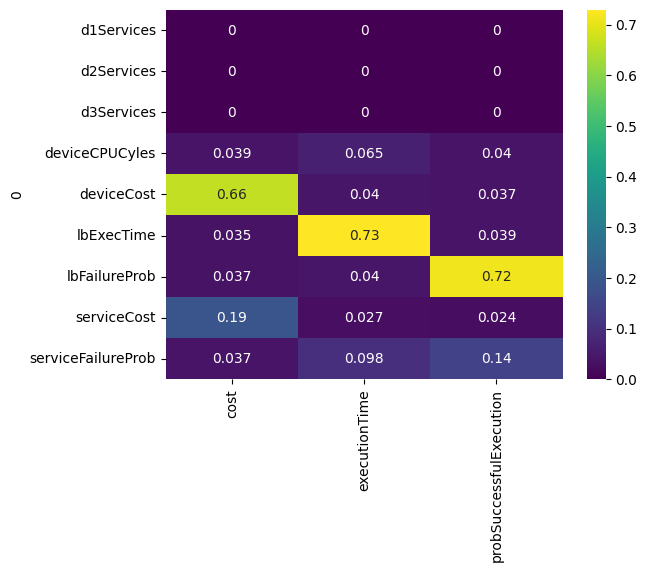

time: 1.73 s (started: 2024-01-14 20:06:25 -03:00)


In [29]:
x = experiments_df
y = outcomes

fs = feature_scoring.get_feature_scores_all(x, y) #, mode=feature_scoring.CLASSIFICATION)
sns.heatmap(fs, cmap='viridis', annot=True)
plt.savefig('feature-scoring1.png')
plt.show()

In [30]:
fs

,cost,executionTime,probSuccessfulExecution
0,,,
d1Services,0.000000,0.000000,0.000000
d2Services,0.000000,0.000000,0.000000
d3Services,0.000000,0.000000,0.000000
deviceCPUCyles,0.039422,0.064519,0.039676
deviceCost,0.661682,0.040447,0.037186
lbExecTime,0.035470,0.729319,0.039362
lbFailureProb,0.036662,0.040467,0.715057
serviceCost,0.189394,0.027392,0.023994
serviceFailureProb,0.037370,0.097856,0.144725


time: 9.71 ms (started: 2024-01-14 20:06:26 -03:00)


In [31]:
fs.sort_values(ascending=False, by='cost')['cost'] # Example of ordering by cost

0
deviceCost            0.661682
serviceCost           0.189394
deviceCPUCyles        0.039422
serviceFailureProb    0.037370
lbFailureProb         0.036662
lbExecTime            0.035470
d1Services            0.000000
d2Services            0.000000
d3Services            0.000000
Name: cost, dtype: float64

time: 9.53 ms (started: 2024-01-14 20:06:26 -03:00)


### **Sensitivity analysis (w.r.t. outcomes)**

In [32]:
sa_results = perform_experiments(models=model, scenarios=128, policies=1, #=128
                                 lever_sampling= Samplers.SOBOL,
                                 uncertainty_sampling= Samplers.SOBOL)

sa_experiments, sa_outcomes = sa_results

[MainProcess/INFO] performing 1792 scenarios * 8 policies * 1 model(s) = 14336 experiments
100%|██████████████████████████████████| 14336/14336 [00:06<00:00, 2064.54it/s]
[MainProcess/INFO] experiments finished


time: 7.04 s (started: 2024-01-14 20:06:26 -03:00)


In [33]:
sa_experiments

,deviceCPUCyles,deviceCost,lbExecTime,lbFailureProb,serviceCost,serviceFailureProb,d1Services,d2Services,d3Services,scenario,policy,model
0,124,15,26,17,3,28,2,5,1,1352,1344,archexploration
1,141,15,26,17,3,28,2,5,1,1353,1344,archexploration
2,124,1,26,17,3,28,2,5,1,1354,1344,archexploration
3,124,15,18,17,3,28,2,5,1,1355,1344,archexploration
4,124,15,26,23,3,28,2,5,1,1356,1344,archexploration
...,...,...,...,...,...,...,...,...,...,...,...,...
14331,146,2,15,14,4,44,2,5,1,3139,1351,archexploration
14332,146,2,10,31,4,44,2,5,1,3140,1351,archexploration
14333,146,2,10,14,4,44,2,5,1,3141,1351,archexploration
14334,146,2,10,14,4,12,2,5,1,3142,1351,archexploration


time: 28.1 ms (started: 2024-01-14 20:06:34 -03:00)


In [34]:
# For parameters
uncertainties_problem = get_SALib_problem(model.uncertainties)
print('----', 'executionTime')
Si_1 = sobol.analyze(uncertainties_problem, sa_outcomes['executionTime'], calc_second_order=True, print_to_console=True)
print('----', 'probSuccessfulExecution')
Si_2 = sobol.analyze(uncertainties_problem, sa_outcomes['probSuccessfulExecution'], calc_second_order=True, print_to_console=True)
print('----', 'cost')
Si_3 = sobol.analyze(uncertainties_problem, sa_outcomes['cost'], calc_second_order=True, print_to_console=True)

---- executionTime
                          ST   ST_conf
deviceCPUCyles      0.042709  0.003609
deviceCost          0.000000  0.000000
lbExecTime          0.878137  0.058925
lbFailureProb       0.000000  0.000000
serviceCost         0.000000  0.000000
serviceFailureProb  0.084368  0.007307
                          S1   S1_conf
deviceCPUCyles      0.048163  0.016374
deviceCost          0.000000  0.000000
lbExecTime          0.884546  0.068557
lbFailureProb       0.000000  0.000000
serviceCost         0.000000  0.000000
serviceFailureProb  0.082391  0.026852
                                            S2       S2_conf
(deviceCPUCyles, deviceCost)         -0.011160  2.217681e-02
(deviceCPUCyles, lbExecTime)         -0.017149  3.519482e-02
(deviceCPUCyles, lbFailureProb)      -0.011160  2.217681e-02
(deviceCPUCyles, serviceCost)        -0.011160  2.217681e-02
(deviceCPUCyles, serviceFailureProb) -0.007378  2.328063e-02
(deviceCost, lbExecTime)              0.000000  7.354820e-17
(deviceC

In [35]:
def show_sobol(problem, Si, title='', filename=None):
    scores_filtered = {k:Si[k] for k in ['ST','ST_conf','S1','S1_conf']}
    Si_df = pd.DataFrame(scores_filtered, index=problem['names'])

    sns.set_style('white')
    fig, ax = plt.subplots(1)

    indices = Si_df[['S1','ST']]
    err = Si_df[['S1_conf','ST_conf']]

    indices.plot.bar(yerr=err.values.T,ax=ax)
    fig.set_size_inches(8,6)
    fig.subplots_adjust(bottom=0.3)
    plt.title(title)
    if filename is not None:
        plt.savefig(filename)
    plt.show()

time: 2.35 ms (started: 2024-01-14 20:06:34 -03:00)


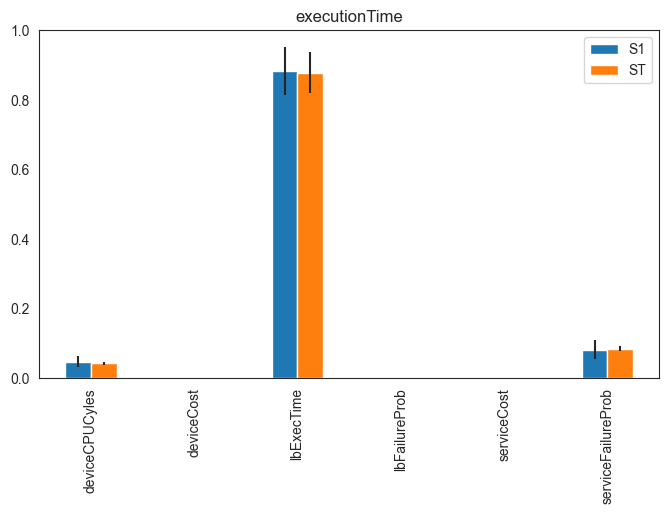

time: 847 ms (started: 2024-01-14 20:06:34 -03:00)


In [36]:
show_sobol(uncertainties_problem, Si_1, title='executionTime', filename='sobol_executiontime1.png')

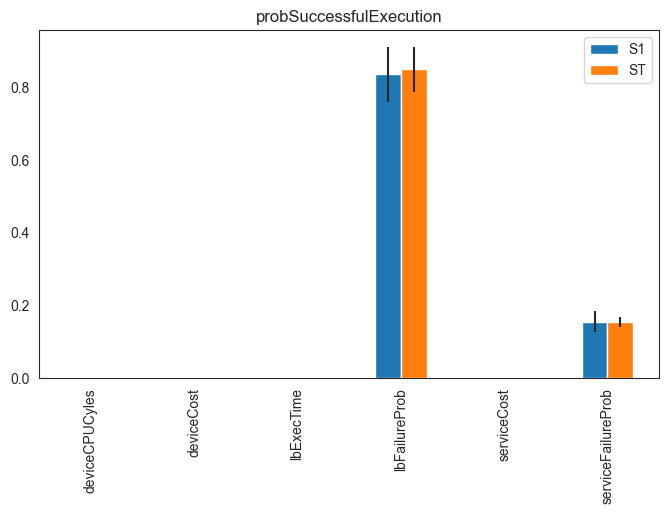

time: 636 ms (started: 2024-01-14 20:06:35 -03:00)


In [37]:
show_sobol(uncertainties_problem, Si_2, title='probSuccessfulExecution', filename='sobol_probsuccessfulexecution1.png')

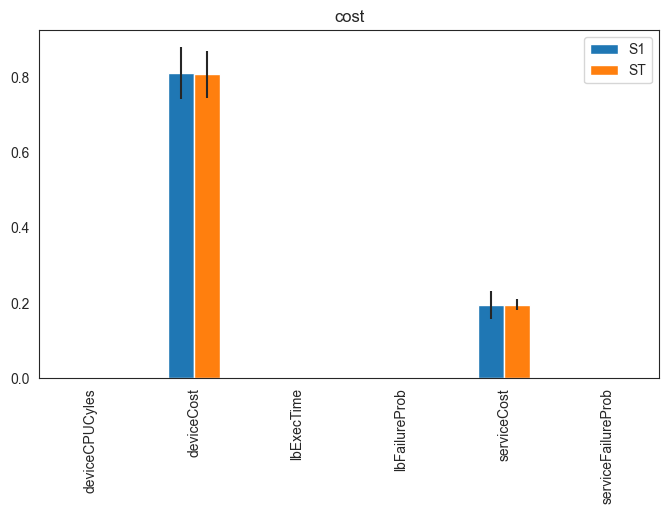

time: 780 ms (started: 2024-01-14 20:06:36 -03:00)


In [38]:
show_sobol(uncertainties_problem, Si_3, title='cost', filename='sobol_cost1.png')

In [39]:
# For levers
levers_problem = get_SALib_problem(model.levers)
print('----', 'executionTime')
Si_4 = sobol.analyze(levers_problem, sa_outcomes['executionTime'], calc_second_order=True, print_to_console=True)
print('----', 'probSuccessfulExecution')
Si_5 = sobol.analyze(levers_problem, sa_outcomes['probSuccessfulExecution'], calc_second_order=True, print_to_console=True)
print('----', 'cost')
Si_6 = sobol.analyze(levers_problem, sa_outcomes['cost'], calc_second_order=True, print_to_console=True)

---- executionTime
                  ST   ST_conf
d1Services  0.496027  0.045692
d2Services  0.317268  0.041703
d3Services  0.529408  0.046127
                  S1   S1_conf
d1Services -0.341681  0.041384
d2Services  0.316266  0.048152
d3Services  0.516981  0.051107
                                S2   S2_conf
(d1Services, d2Services)  0.650096  0.052269
(d1Services, d3Services)  0.205204  0.060231
(d2Services, d3Services) -0.723913  0.069084
---- probSuccessfulExecution
                  ST   ST_conf
d1Services  0.389170  0.037449
d2Services  0.812467  0.050043
d3Services  0.433310  0.038285
                  S1   S1_conf
d1Services  0.130156  0.039808
d2Services  0.369668  0.063654
d3Services  0.425259  0.043874
                                S2   S2_conf
(d1Services, d2Services) -0.297776  0.065921
(d1Services, d3Services)  0.003623  0.063315
(d2Services, d3Services) -0.094164  0.072256
---- cost
                  ST   ST_conf
d1Services  0.415520  0.041767
d2Services  0.511485  0.

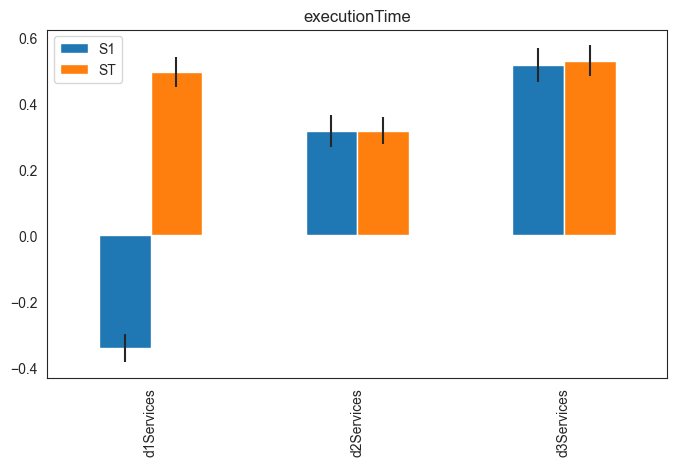

time: 448 ms (started: 2024-01-14 20:06:37 -03:00)


In [40]:
show_sobol(levers_problem, Si_4, title='executionTime')

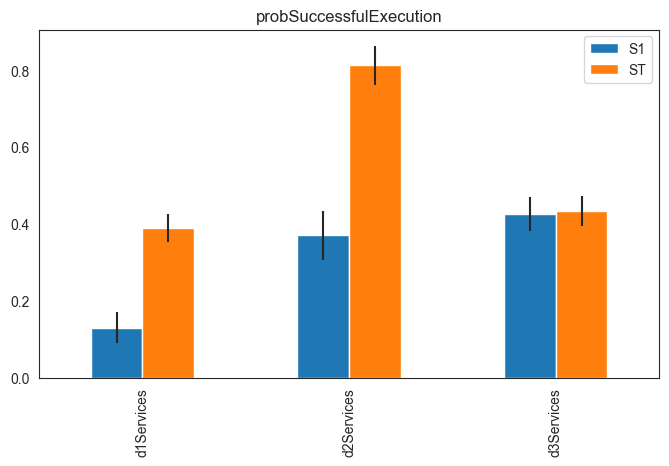

time: 465 ms (started: 2024-01-14 20:06:37 -03:00)


In [41]:
show_sobol(levers_problem, Si_5, title='probSuccessfulExecution')

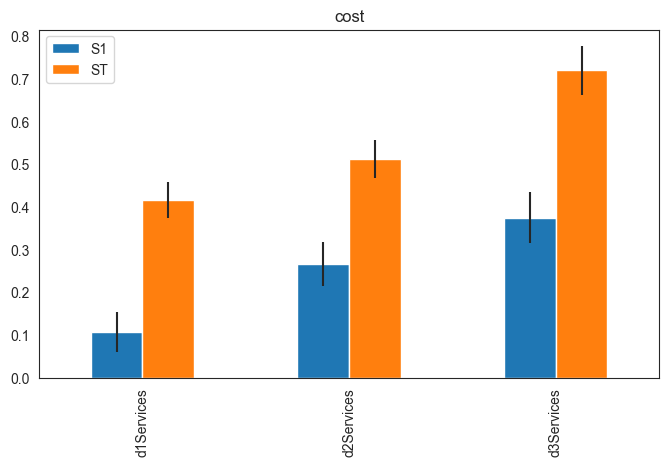

time: 470 ms (started: 2024-01-14 20:06:38 -03:00)


In [42]:
show_sobol(levers_problem, Si_6, title='cost')

---